# Notebook Instructions

1. If you are new to Jupyter notebooks, please go through this introductory manual <a href='https://quantra.quantinsti.com/quantra-notebook' target="_blank">here</a>.
1. Any changes made in this notebook would be lost after you close the browser window. **You can download the notebook to save your work on your PC.**
1. Before running this notebook on your local PC:<br>
i.  You need to set up a Python environment and the relevant packages on your local PC. To do so, go through the section on "**Run Codes Locally on Your Machine**" in the course.<br>
ii. You need to **download the zip file available in the last unit** of this course. The zip file contains the data files and/or python modules that might be required to run this notebook.

## Performance Metrics

In the previous notebook, you learned about trade-level analytics which helps you to evaluate your strategy after a trade has been executed. However, these metrics do not consider how the strategy performed within a trade. 

In this notebook, you will learn about some popular metrics that will help you analyse in depth what happens between entry and exit time. The notebook is structured as follows:
1. [Read the Data](#read)
2. [Different Performance Measures](#perf)<br>
   2.1. [Equity Curve](#equi)<br>
   2.2. [CAGR](#cagr)<br>
   2.3. [Annualised Volatility](#vol)<br>
   2.4. [Sharpe Ratio](#sharpe)<br>
   2.5. [Maximum Drawdown](#mdd)<br>
3. [Function to Analyse the Strategy Performance](#function)    
   
## Import the Libraries 

In [1]:
# For data manipulation
import pandas as pd
import numpy as np
import datetime

# For plotting
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

# To ignore warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

<a id='read'></a>
## Read the Data 

We have saved the close price data and trade signals generated according to the head and shoulders pattern in a CSV file named `signals_hs_spy_1993_2018.csv`. We will also need the trade details saved in `trades_hs_spy_1993_2018.csv`. We can read these files using the `pandas.read_csv()` method. 

In [2]:
# Read the price data and trade signals
data = pd.read_csv('../data_modules/signals_hs_spy_1993_2018.csv', index_col=0)

# Convert the index to datetime
data.index = pd.to_datetime(data.index)

# Read the trade details
trades = pd.read_csv('../data_modules/trades_hs_spy_1993_2018.csv', index_col=0)

# Convert the index to datetime
trades['entry_date'] = pd.to_datetime(trades['entry_date'])
trades['exit_date'] = pd.to_datetime(trades['exit_date'])

# Display the top five trades in the dataframe
trades.head()

,entry_date,entry_price,position,exit_date,exit_type,exit_price,PnL
0,1993-11-04,26.91,-1.0,1993-12-22,SL,27.65,-0.74
0,2001-06-13,83.25,-1.0,2002-07-18,TP,59.53,23.72
0,2003-08-05,66.50,-1.0,2003-08-29,SL,69.96,-3.46
0,2006-02-07,90.53,-1.0,2006-02-16,SL,93.18,-2.65
0,2011-09-22,91.54,-1.0,2011-10-14,SL,99.42,-7.88


## Update Trading Signals in DataFrame
The following code iterates over the `trades` DataFrame to update the `signal` column in the data DataFrame. For each trade in trades, it extracts the entry and exit dates, as well as the position (e.g., -1 for short positions). 

The code then updates the `signal` column in data for the date range between the entry and exit dates with the corresponding position. This process helps in marking the periods during which certain trades were active in the `data` DataFrame.

In [3]:
# Iterate over each row in the 'trades' DataFrame
for index, trade in trades.iterrows():
    # Extract the entry date of the trade
    entry_date = trade['entry_date']
    
    # Extract the exit date of the trade
    exit_date = trade['exit_date']
    
    # Extract the position of the trade (e.g., -1 for short)
    position = trade['position']
    
    # Update the 'signal' column in the 'data' DataFrame for the date range
    # between the entry date and the exit date with the corresponding position
    data.loc[entry_date:exit_date, 'signal'] = position

<a id='perf'></a>
## Different Performance Measures

Before investing in a strategy you should have a clear understanding of its performance within trades. Just looking at the entry and exit values is not enough. You should also be able to answer questions like:<br>

<b>How much risk are you undertaking with this trading strategy?</b><br>
<b>How much drawdown should you expect with this strategy?</b><br>

Therefore, we have broken down some popular performance metrics to answer these questions. 

We will start by creating a dataframe `performance_metrics` to store all the values we will calculate in this notebook. 

In [4]:
# Create a dataframe to store performance metrics
performance_metrics = pd.DataFrame(index=['Strategy'])

<a id='equi'></a>
### Equity Curve

An equity curve helps you visualise how the strategy returns have changed over a period of time. If the curve has a consistently positive slope, it indicates that the trading strategy is profitable. A negative slope shows that it is generating negative returns.

The equity curve also helps in visualising the drawdowns incurred within a strategy. 

To find the equity curve, we will first calculate the strategy's returns and then calculate the cumulative returns. Finally, we will plot the `cumulative_returns` column of our dataset.

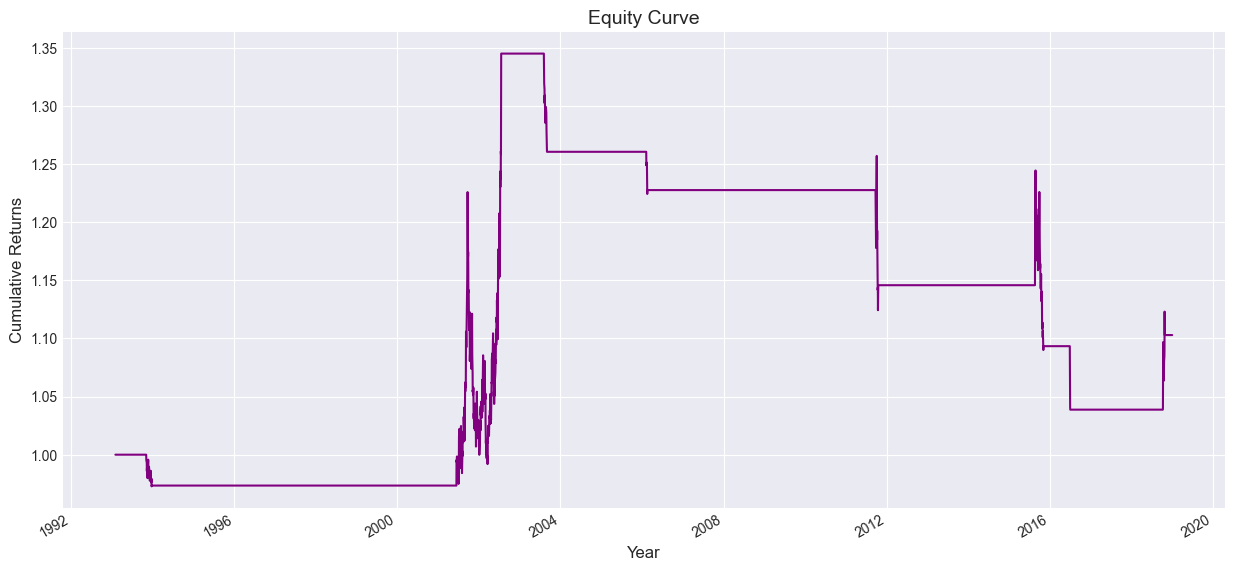

In [5]:
# Calculate strategy returns
data['strategy_returns'] = data.signal.shift(1) * data.Close.pct_change()

# Calculate cumulative strategy returns
data['cumulative_returns'] = (data['strategy_returns'] + 1.0).cumprod()

# Plot the cumulative strategy returns
(data['cumulative_returns'].plot(figsize=(15, 7), color='purple'))

# Set the title and axis labels
plt.title('Equity Curve', fontsize=14)
plt.ylabel('Cumulative Returns', fontsize = 12)
plt.xlabel('Year', fontsize = 12)

# Display the chart
plt.show()

Overall, we can see that the curve shows an increase in returns.  But through an equity curve, we can also analyse what happened within the trades. Let us take an example of a losing trade from our trade sheet. 

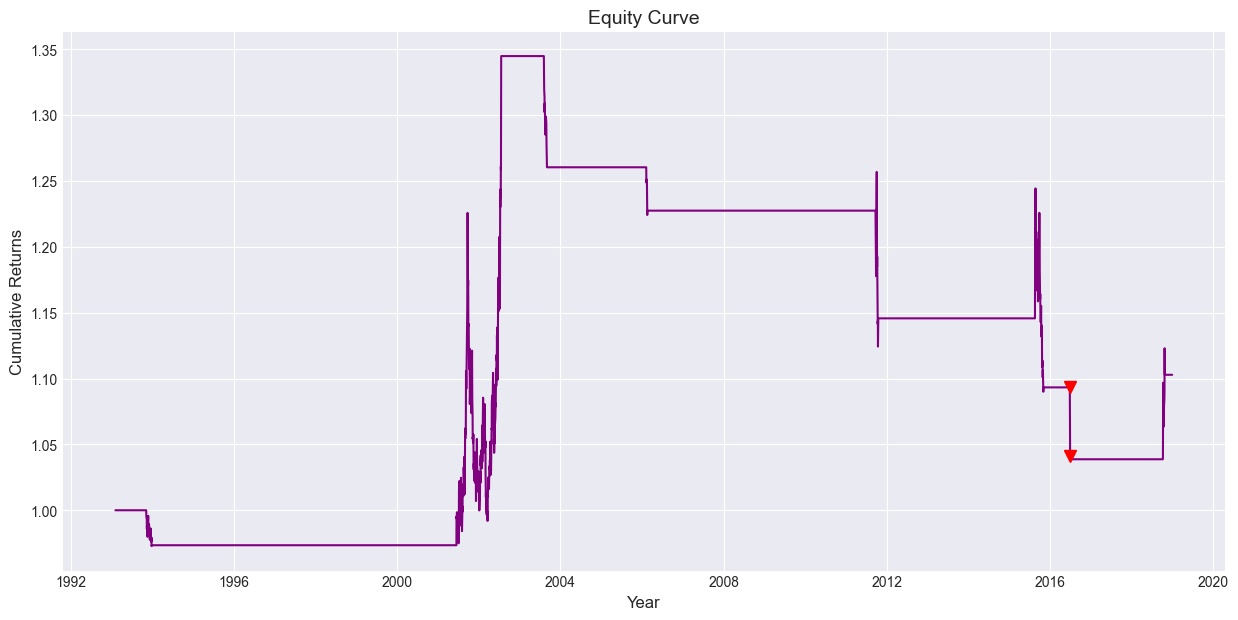

In [6]:
# Find entry and exit dates of largest loss
loss_entry = trades[trades.PnL == trades.PnL.min()]['entry_date'].values[0]
loss_exit = trades[trades.PnL == trades.PnL.min()]['exit_date'].values[0]

# Convert to datetime
loss_entry_date = pd.to_datetime(loss_entry)
loss_exit_date = pd.to_datetime(loss_exit)

# Plot the points on equity curve
plt.figure(figsize=(15, 7))
plt.plot(data['cumulative_returns'], color='purple')
plt.plot(loss_entry_date,
         data.loc[loss_entry_date].cumulative_returns, 'v', color='r', markersize=8)
plt.plot(loss_exit_date, data.loc[loss_exit_date].cumulative_returns, 'v', color='r', markersize=8)

# Set the title and axis labels
plt.title('Equity Curve', fontsize=14)
plt.xlabel('Year', fontsize = 12)
plt.ylabel('Cumulative Returns', fontsize = 12)

# Display the chart
plt.show()

The entry and exit dates are shown by the two red markers in the above graph. With the equity curve, you can see the price drop within the losing trade. 

<a id='cagr'></a>
### CAGR
CAGR stands for Compound Annual Growth Rate. It is the measure of a strategy's annual growth rate over time, with the effect of compounding taken into account. It is calculated by the following formula: 

$$ CAGR = \left(\left(\frac{EV}{BV}\right)^{\frac{1}{n}} -1\right)*100 $$

where
* $EV$ is the ending value
* $BV$ is the beginning value
* $n$ is the number of years


In [7]:
# Total number of trading candles per day
candle_difference = data.index.to_series().diff().mean().days
    
# Number of trading candles per day
if candle_difference >= 1:
    n = np.floor(candle_difference)
else:
    n = data.loc[datetime.datetime.strftime(
            data.index[-1].date(), '%Y-%m-%d')].shape[0]

# Total number of trading candles over time
trading_candles = len(data['cumulative_returns'])

# Calculate compound annual growth rate
performance_metrics['CAGR'] = "{0:.2f}%".format((data.cumulative_returns.iloc[-1]**(252*n/trading_candles)-1)*100)

# Display performance metrics
performance_metrics.T

,Strategy
CAGR,0.38%


We have got a CAGR of 0.38%. This means our initial capital appreciated annually by 0.38% with this strategy. 

<a id='hist'></a>
### Histogram of Returns
A histogram of returns is a chart that shows us the distribution of our strategy returns.

We will plot the histogram of `strategy_returns` using the `hist` method. 

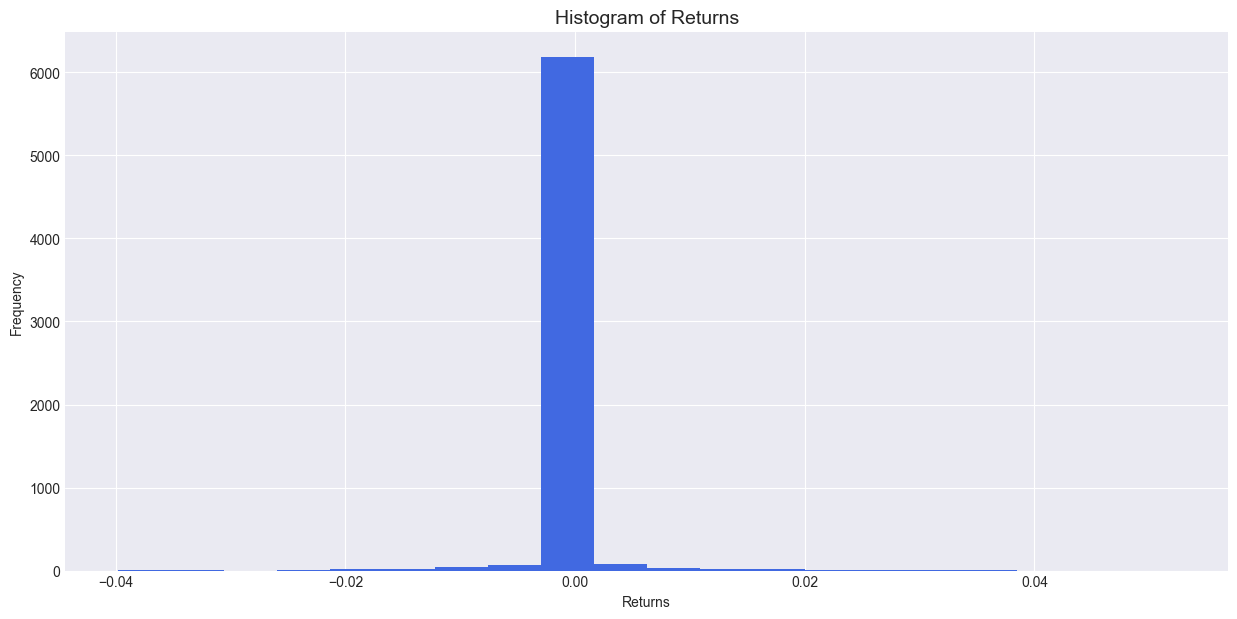

In [8]:
# Plot the histogram of returns
data.strategy_returns.hist(bins=20, figsize=(15, 7), color='royalblue')

# Set the title
plt.title('Histogram of Returns', fontsize=14)

# Set the labels
plt.xlabel('Returns')
plt.ylabel('Frequency')

# Display the chart
plt.show()

<a id='vol'></a>
### Annualised Volatility
Volatility is the rate at which the price of a security increases or decreases for a given set of returns over a period of time. 

We will calculate the annualised volatility by taking the standard deviation of the `strategy_returns`. To annualise them we will multiply it by the square root of (252 * Total number of trading candles per day). Since we're working with daily data, the total number of trading candles per day will be 1. 

In [9]:
# Calculate annualised volatility
performance_metrics['Annualised Volatility'] = "{0:.2f}%".format(
    data['strategy_returns'].std()*np.sqrt(252*n) * 100)

# Display performance metrics
performance_metrics.T

,Strategy
CAGR,0.38%
Annualised Volatility,5.21%


The strategy's annualised volatility works out to be 5.21%. This indicates that the returns for our strategy returns can fluctuate by 5.21% on average during one year. 

<a id='sharpe'></a>
### Sharpe Ratio

Sharpe ratio measures the performance of a strategy when compared to a risk-free rate. It is the ratio of the returns earned in excess of the risk-free rate per unit of risk taken. 
It is calculated as below:
$$ Sharpe~ratio = \frac{R_x-R_f}{\sigma_x}$$

where
* $R_x$ is the mean return of the strategy
* $R_f$ is the risk-free rate
* $\sigma_x$ is the volatility

Sharpe ratios greater than 1 are preferable, as it means your returns are greater given the risk you are taking. Generally, a strategy with a higher Sharpe ratio will be preferred over a strategy with a lower Sharpe ratio.

In [10]:
# Set a risk-free rate
risk_free_rate = 0.02/(252*n)

# Calculate Sharpe ratio
performance_metrics['Sharpe Ratio'] = np.sqrt(252*n)*(np.mean(data.strategy_returns) -
                                                    (risk_free_rate))/np.std(data.strategy_returns)

# Display performance metrics
performance_metrics.T

,Strategy
CAGR,0.38%
Annualised Volatility,5.21%
Sharpe Ratio,-0.285094


<a id='mdd'></a>
### Maximum Drawdown
Maximum drawdown is one of the key measures to assess the risk in a strategy.  In your trading strategy, your returns reduce in value multiple times. These reductions in value are known as drawdowns. The maximum of these drawdown values gives us an estimate of the maximum loss a strategy can incur. Technically, it is defined as the maximum loss from peak to trough for a portfolio.

It signifies the maximum loss from a peak to a trough of a strategy and is expressed in percentage terms. It can be calculated by the following formula: 

$$ Maximum ~Drawdown = \frac{Peak ~value - Trough ~value }{Peak ~value} $$

Generally, a lower magnitude of maximum drawdown is desired. 


In [11]:
# Compute the cumulative maximum
data['Peak'] = data['cumulative_returns'].cummax()

# Compute the drawdown
data['Drawdown'] = ((data['cumulative_returns']-data['Peak'])/data['Peak'])

# Compute the maximum drawdown
performance_metrics['Maximum Drawdown'] =  "{0:.2f}%".format((data['Drawdown'].min())*100)

# Display performance metrics
performance_metrics.T

,Strategy
CAGR,0.38%
Annualised Volatility,5.21%
Sharpe Ratio,-0.285094
Maximum Drawdown,-22.77%


The maximum drawdown works out to be -22.77%. This means you can expect to lose a maximum of around 22.77% when trading with this strategy. Let us also plot all the drawdowns to get an idea of how frequently they occur.

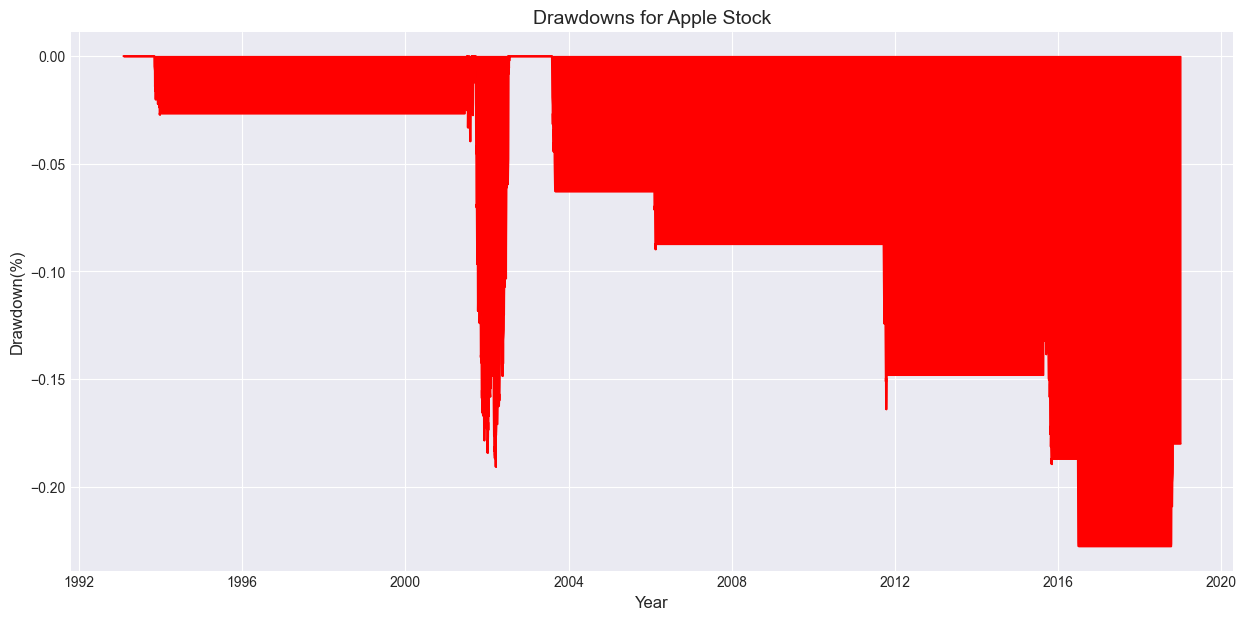

In [12]:
# Define size of graph
plt.figure(figsize=(15, 7))

# Set the title and axis labels
plt.title('Drawdowns for Apple Stock', fontsize=14)
plt.ylabel('Drawdown(%)', fontsize=12)
plt.xlabel('Year', fontsize=12)

# Plot maximum drawdown
plt.plot(data['Drawdown'], color='red')

# Fill in-between the drawdowns
plt.fill_between(data['Drawdown'].index, data['Drawdown'].values, color='red')

# Display the chart
plt.show()

<a id='function'></a>
## Function to Analyse the Strategy Performance

Let's create a function which will help us calculate the performance measures. This would enable us to call the function directly whenever we need to analyse the strategy. We will be using this function recurrently in the upcoming sections.

In [13]:
# For data manipulation
import datetime
import numpy as np
import pandas as pd

# For data visualisation
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

# Create a function to compute and plot the strategy returns
def get_performance_metrics(data, col_names=['Close', 'signal']):

    Close = col_names[0]
    signal = col_names[1]

    # Create a data to store performance metrics
    performance_metrics = pd.DataFrame(index=['Strategy'])

    # -------------------Plot equity curve---------------------

    # Calculate strategy returns
    data['strategy_returns'] = data.signal.shift(1) * data.Close.pct_change()
    
    # Calculate cumulative strategy returns
    data['cumulative_returns'] = (data['strategy_returns'] + 1.0).cumprod()

    # Plot cumulative returns
    data['cumulative_returns'].plot(figsize=(15, 7), color='black')
    plt.title('Equity Curve', fontsize=14)
    plt.ylabel('Returns (in times)', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    plt.show()

    # -------------------Compute CAGR---------------------

    # Total number of trading candles per day
    candle_difference = data.index.to_series().diff().mean().days
    if candle_difference >= 1:
        n = np.floor(candle_difference)
    else:
        n = data.loc[datetime.datetime.strftime(
            data.index[-1].date(), '%Y-%m-%d')].shape[0]
    
    # Total number of trading candles over time
    trading_candles = len(data['cumulative_returns'])
    
    # Calculate compound annual growth rate
    performance_metrics['CAGR'] = "{0:.2f}%".format(
        (data.cumulative_returns.iloc[-1]**(252*n/trading_candles)-1)*100)

    # -------------------Compute Sharpe ratio---------------------

    # Set a risk-free rate
    risk_free_rate = 0.02/(252*n)
    
    # Calculate Sharpe ratio
    performance_metrics['Sharpe Ratio'] = round(np.sqrt(252*n)*(np.mean(data['strategy_returns']) -
                                                                (risk_free_rate))/np.std(data['strategy_returns']), 2)

    # -------------------Compute maximum drawdown---------------------

    # Compute the cumulative maximum
    data['Peak'] = (data['strategy_returns']+1).cumprod().cummax()
    
    # Compute the Drawdown
    data['Drawdown'] = (
        ((data['strategy_returns']+1).cumprod()-data['Peak'])/data['Peak'])*100
    
    # Compute the maximum drawdown
    performance_metrics['Maximum Drawdown'] = "{0:.2f}%".format(
        (data['Drawdown'].min()))

    # -------------------Plot maximum drawdown---------------------

    # Plot maximum drawdown
    data['Drawdown'].plot(figsize=(15, 7), color='red')
   
    # Set the title and axis labels
    plt.title('Drawdowns', fontsize=14)
    plt.ylabel('Drawdown(%)', fontsize=12)
    plt.xlabel('Year', fontsize=12)
    plt.fill_between(data['Drawdown'].index,
                     data['Drawdown'].values, color='red')
    plt.show()

    # Display performance metrics
    print(performance_metrics.T)

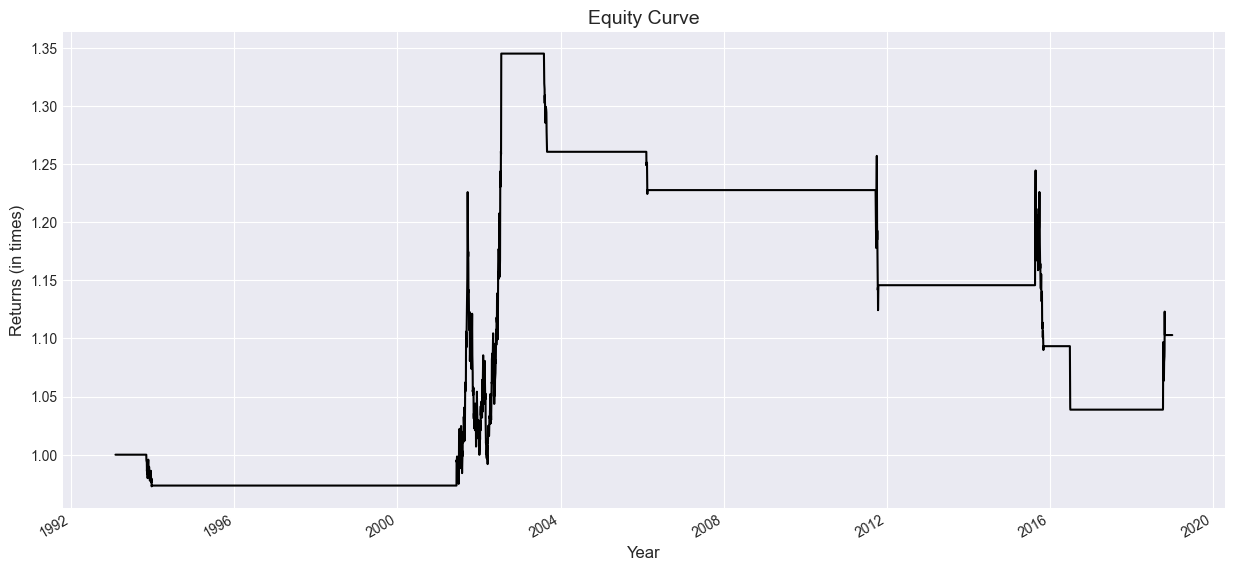

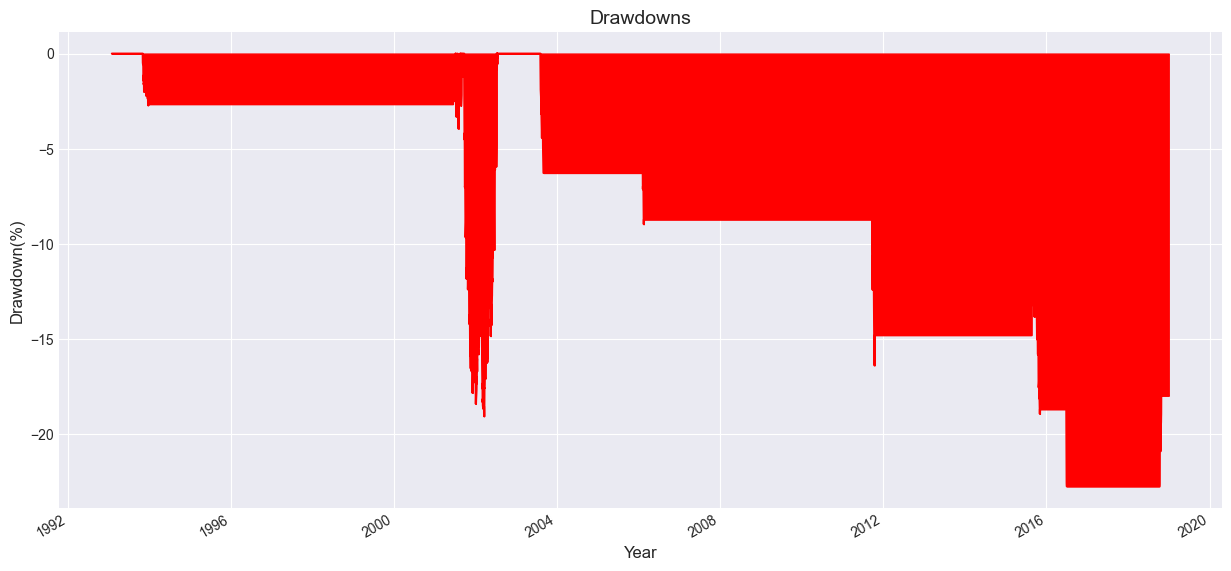

                 Strategy
CAGR                0.38%
Sharpe Ratio        -0.29
Maximum Drawdown  -22.77%


In [14]:
# Call the function
get_performance_metrics(data)

## Conclusion
In this notebook, we learned how to evaluate a strategy's performance in-between the entry and exit period and also how to analyse the risk involved in undertaking these trades. We also created a function which will help us analyse the strategy performance. We will be using this function in the upcoming sections as well.